## Find network assignments



Brain networks were identified in individual subjects by a winner-take-all procedure (similar to that employed in Gordon et al. (2017b)) which assigned each cortical gray matter voxel in a particular subject to one of 14 network templates.
https://www.sciencedirect.com/science/article/pii/S1053811921004419#sec0002


https://github.com/MidnightScanClub/MSCcodebase/blob/master/Utilities/Infomap_wrapper/consensus_maker_knowncolors.m

#### Old & Additional

- reorga files
- plot ind. nets
- old `match_communities_to_networks` function (ChatGPT suggestion)

In [2]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [25]:
source_folder = op.join(bids_folder,'derivatives','networks_infomap')

sub = '09'
hemi = 'both'
confspec='36Pscrub3BPfilter'
preferred_number_of_modules = 15 #'None'
thresh_conn = '0.1'

fn_path = op.join(source_folder, f'sub-{sub}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
print(f'Module mapping file already exists: {fn_path}. Skipping to plotting')
sub_module_mapping = np.load(fn_path)
print(sub_module_mapping.shape)

Module mapping file already exists: /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap/sub-09_module_mapping_infomap_hemi-both_thresh-0.1_prefNmod-15_confspec-36Pscrub3BPfilter.npy. Skipping to plotting
(18715, 2)


In [38]:
sub = f'{int(sub):02d}'
preferred_number_of_modules = 10
confspec='36Pscrub3BPfilter'

source_folder = op.join(bids_folder,'derivatives','networks_infomap')
plot_folder = op.join(bids_folder,'plots_and_ims','networks_infomap')

fn_subject_modules = op.join(source_folder, f'sub-{sub}_module_mapping_infomap_hemi-both_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
module_mapping = np.load(fn_subject_modules)

subject_labels = module_mapping[:, 1]  

In [4]:
# target
preferred_number_of_modules = 15
fn_path = op.join(source_folder, f'sub-average_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
target_module_mapping = np.load(fn_path)
print(target_module_mapping.shape)

np.unique(target_module_mapping[:,1], return_counts=True)


(18715, 2)


(array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 array([ 621, 2831, 4114, 2590, 2646, 2282, 1248, 1198,  249,  306,  210,
         215,  157,   44,    2,    2]))

In [5]:
network_name_dict = {
    1:'dorsalMotor',
    2: 'Default',
    3: 'DorsalAttention',
    4: 'Visual',
    5: 'CinguloOpercular', # net 8 could be added for alignment with Cole-Anticevic
    6: 'ventralMotorAuditory', # + auditory
    7: 'FrontoParietal',
    8: 'medialMultimodal', # own naming
    9: 'parietalMemory',# have it also in Gordon 2017
    10: 'Salience',
    11: 'Language', # ventral attention ?
    12: 'posteriorMultimodal', # from Cole Anticevic
}

# derived by plotting every module separately and eyeballing the labels

In [ ]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping, get_glasser_parcels
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , 
                                     labeling_glasser, mask=mask_glasser, fill=0) #, fill=np.nan) #grad_sub[n_grad-1]

print(caNets_fsav5_mapping[mask].shape)

In [ ]:
from net_assign_plots import assign_subject_communities_to_reference

target_labels = target_module_mapping[:, 1]  
target_labels_caNets, assignments = assign_subject_communities_to_reference(target_labels,caNets_fsav5_mapping[mask],  jaccard_threshold=0.1)
fn_target_labels_caNets = op.join(source_folder, f'sub-average_target_labels_caNets_hemi-{hemi}_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
#np.save(fn_target_labels_caNets, target_labels_caNets)

In [ ]:
from net_assign_plots import assign_subject_communities_to_reference

subject_labels = sub_module_mapping[:, 1]  
#target_labels = target_module_mapping[:, 1]  
relabeled_subject, assignments = assign_subject_communities_to_reference(subject_labels, target_labels_caNets,  jaccard_threshold=0.1)
print(np.unique(caNets_fsav5_mapping[mask], return_counts=True))
print(np.unique(relabeled_subject, return_counts=True))

assignments

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), array([ 209,  695, 2146, 3120, 2914, 1285, 1060, 2578,  531, 3382,  301,
        306,  188]))
(array([-1,  2,  3,  5,  6,  8,  9]), array([1426, 2753, 4995, 3563,  249,  974, 4755]))


[(1, 3, 0.39079438421894436),
 (2, 5, 0.43728100911002105),
 (3, 9, 0.5191513330829891),
 (4, 2, 0.5888758092995879),
 (5, -1, 0.06973923590054579),
 (6, 8, 0.47837658017298734),
 (7, 9, 0.10155370412069353),
 (8, 6, 0.11091234347048301),
 (9, -1, 0.055049216186656945)]

In [27]:
import matplotlib.patches as mpatches
import hcp_utils as hcp
from matplotlib.colors import ListedColormap

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
# Add grey color at the beginning
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_ca = ListedColormap( np.vstack([grey, rgb]))
#cmap_ca = ListedColormap(rgb)

In [28]:
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] =  relabeled_subject 
surf_map = modules_fsav5

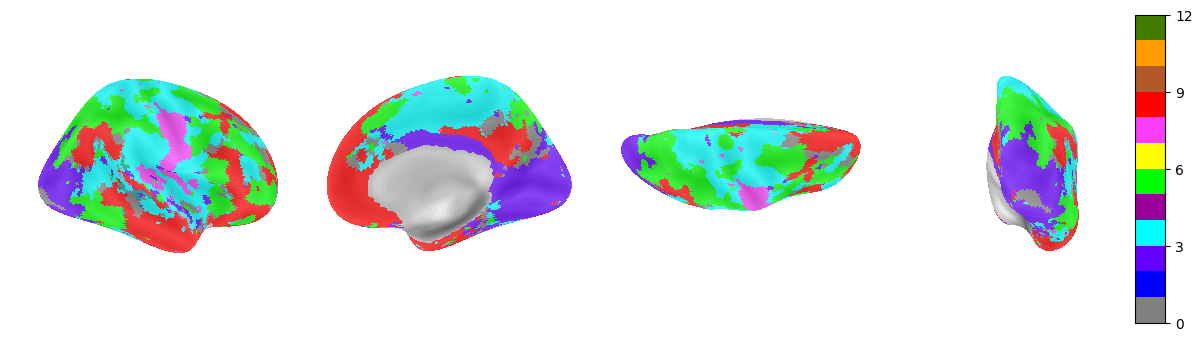

In [29]:
# plot only one module to see which is which
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = cmap_ca #'Paired'#''viridis' # 

hemi_to_plot = 'R'
i = 0 if hemi_to_plot == 'L' else 1

# modules got from run infomap on both, but plot only one hemi
modules_fsav5_hemi = np.split(surf_map,2)[i]
modules_fsav5_hemi.shape

map = modules_fsav5_hemi
hemi_to_plot = hemi if hemi != 'both' else hemi_to_plot
surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'posterior' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, avg_method = 'median',# infl_right # pial_right
            view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            vmin = 0, vmax=12,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)
#figure.suptitle(f'net label {net_label}', y=0.75)
                #sub {sub}, hemi {hemi} \n thresh {thresh_conn} \n prefNmod {preferred_number_of_modules}', y=0.75)

In [34]:
np.unique(surf_map, return_counts=True)

(array([-1.,  2.,  3.,  5.,  6.,  8.,  9., nan]),
 array([1426, 2753, 4995, 3563,  249,  974, 4755, 1769]))

### Collapse across treshold & cleanup



In [42]:
source_folder = op.join(bids_folder,'derivatives','networks_infomap')

sub = '01'
hemi = 'both'
confspec='36Pscrub3BPfilter'
preferred_number_of_modules = 'None'
sub_module_mappings_relabelled = []
for thresh_conn in ['0.02','0.05','0.1', '0.2', '0.3', '0.5']:
    fn_path = op.join(source_folder, f'sub-{sub}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
    sub_module_mapping = np.load(fn_path)
    subject_labels = sub_module_mapping[:, 1]  
    relabeled_subject, assignments = assign_subject_communities_to_reference(subject_labels, target_labels_caNets,  jaccard_threshold=0.1)
    sub_module_mappings_relabelled.append(relabeled_subject)

In [ ]:
from fit_assign_plot_ind_nets import get_consensus_assignment
consensus_labels = get_consensus_assignment(sub_module_mappings_relabelled)

In [56]:
import numpy as np
from nilearn import surface

def compute_vertex_areas(coords, faces):
    """
    Approximate per-vertex surface area from triangle faces.
    """
    def triangle_area(v0, v1, v2):
        return 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1)

    tris = coords[faces]  # (n_faces, 3, 3)
    areas = triangle_area(tris[:, 0], tris[:, 1], tris[:, 2])  # (n_faces,)

    vertex_areas = np.zeros(coords.shape[0])
    for i in range(3):
        np.add.at(vertex_areas, faces[:, i], areas / 3.0)

    return vertex_areas


In [60]:
import numpy as np
import networkx as nx

def build_surface_graph(faces, n_vertices):
    """Builds an undirected graph from surface mesh faces."""
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))
    for tri in faces:
        G.add_edges_from([(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])])
    return G

def remove_small_clusters_surface(consensus_map, faces, vertex_areas, area_thresh=30.0):
    """Removes contiguous network patches on surface < area_thresh mm²."""
    cleaned = consensus_map.copy()
    n_vertices = cleaned.shape[0]
    G = build_surface_graph(faces, n_vertices)

    for label in np.unique(cleaned):
        if label == -1:
            continue

        # Subgraph of current label
        label_nodes = np.where(cleaned == label)[0]
        subgraph = G.subgraph(label_nodes)

        # Find connected components
        for component in nx.connected_components(subgraph):
            area = vertex_areas[list(component)].sum()
            if area < area_thresh:
                cleaned[list(component)] = -1

    return cleaned


In [ ]:
from nilearn import datasets, surface

# Load mesh (e.g., fsaverage5)
fsavg = datasets.fetch_surf_fsaverage("fsaverage5")
coords, faces = surface.load_surf_mesh(fsavg.pial_left)

# Compute vertex areas
vertex_areas = compute_vertex_areas(coords, faces)

# Clean
consensus_cleaned = remove_small_clusters_surface(
    consensus_labels, faces, vertex_areas, area_thresh=30.0
)


In [63]:
consensus_labels.shape

(18715,)

In [59]:
import networkx as nx


Text(0.5, 0.75, 'sub 01')

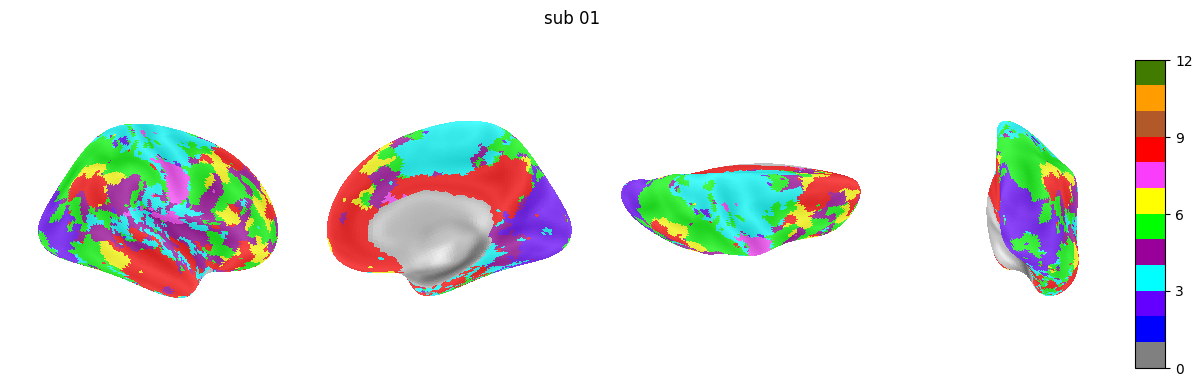

In [48]:
from utils import plot_nets_CAcolors
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R')
figure.suptitle(f'sub {sub}', y=0.75)

In [65]:
sub = '04'
sub_module_mappings_relabelled = np.load(f'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full/sub-{sub}_allThresholds_confspec-36Pscrub3BPfilter.npy')

In [ ]:
np.unique(sub_module_mappings_relabelled[0], return_counts=True)


(array([-1,  2,  3,  9]), array([3042, 2783, 7488, 5402]))

In [68]:
np.unique(sub_module_mappings_relabelled[1], return_counts=True)


(array([-1,  2,  3,  9]), array([1689, 3142, 8194, 5690]))

In [69]:
np.unique(sub_module_mappings_relabelled[2], return_counts=True)


(array([-1,  2,  3,  4,  5,  7,  8,  9]),
 array([3099, 2558, 3229, 2959, 2148, 2085,  447, 2190]))

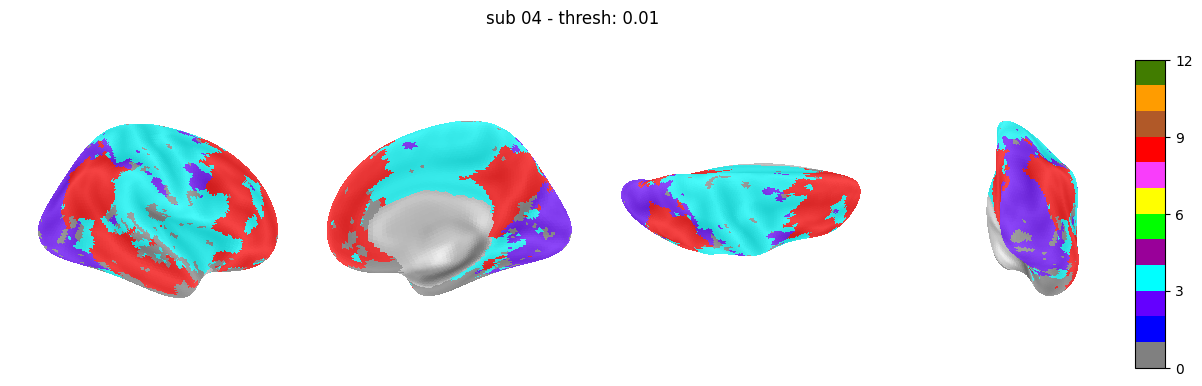

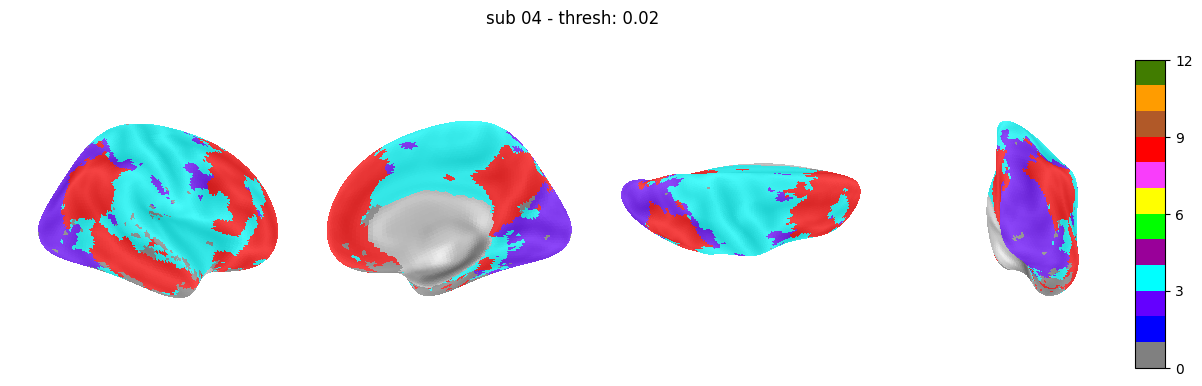

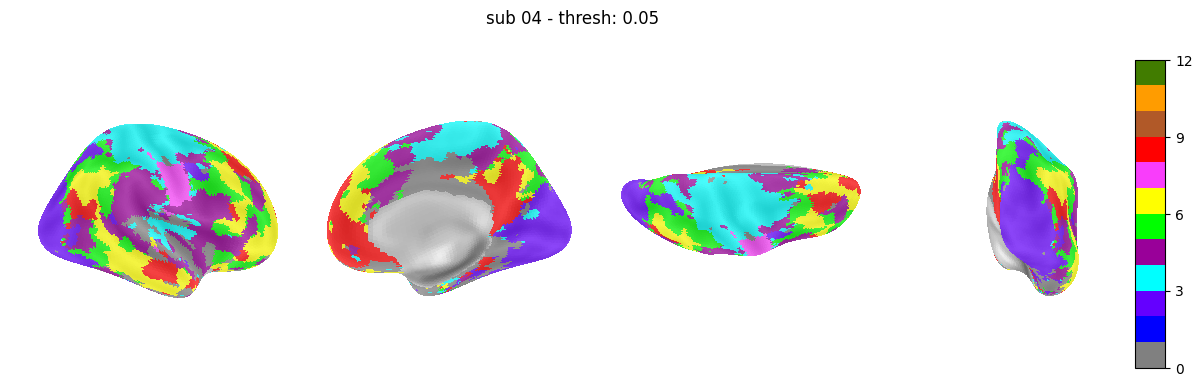

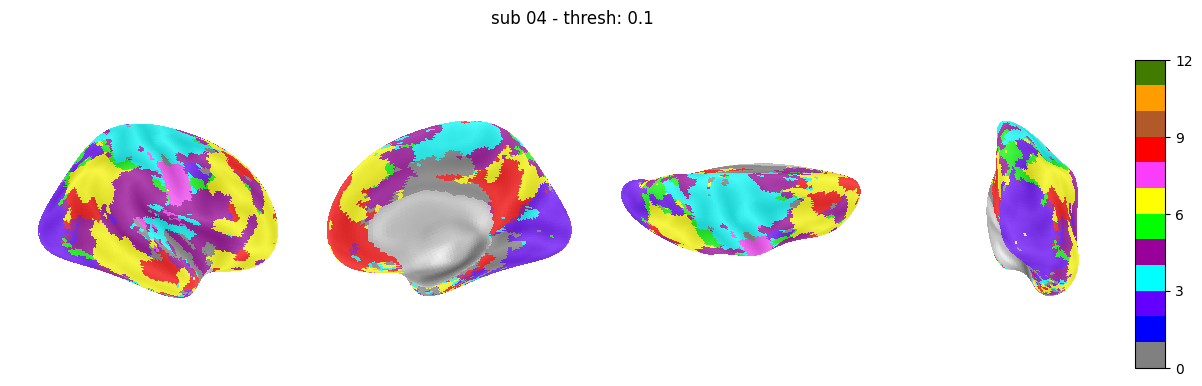

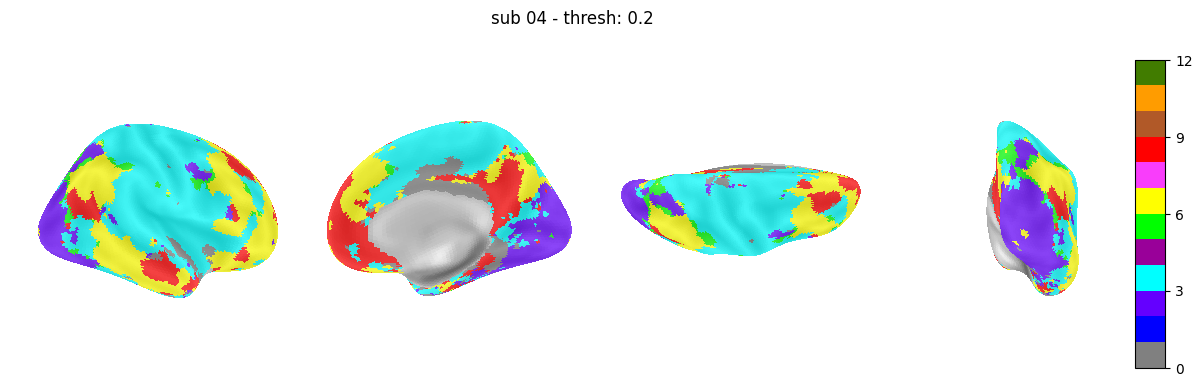

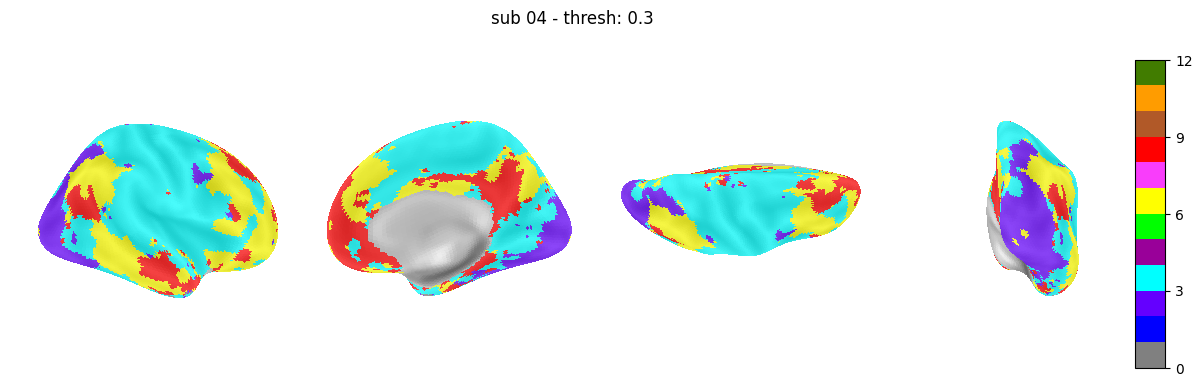

In [66]:
threshs = ['0.02','0.05','0.1', '0.2', '0.3', '0.5']
threshs = ['0.01','0.02','0.05','0.1', '0.2', '0.3']

for thresh_conn, mapping in zip(threshs, sub_module_mappings_relabelled):
    modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
    modules_fsav5[mask] = mapping

    figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R')
    figure.suptitle(f'sub {sub} - thresh: {thresh_conn}', y=0.75)
    fn_plot = op.join(plot_folder, f'sub-{sub}_thresh-{thresh_conn}.png')
    plt.savefig(fn_plot)


## OLD & Additional

In [ ]:
import numpy as np
from collections import defaultdict
from sklearn.metrics import jaccard_score

def match_communities_to_networks(subject_labels, target_labels, known_networks, jaccard_threshold=0.1):
    """
    subject_labels: 1D numpy array of community labels for subject
    target_labels: 1D numpy array of known network labels
    known_networks: List of network labels to match to (ordered by priority)
    jaccard_threshold: Minimum Jaccard score for valid match

    Returns:
        relabeled_subject: 1D numpy array with subject labels reassigned to network IDs
        matched_pairs: list of (subject_label, matched_network_label, jaccard_score)
    """
    subject_labels = np.array(subject_labels)
    target_labels = np.array(target_labels)
    unique_subject_comms = np.unique(subject_labels)
    unique_subject_comms = unique_subject_comms[unique_subject_comms != -1]  # exclude unassigned if needed

    relabeled_subject = np.full_like(subject_labels, fill_value=-1)
    matched_comms = set()
    matched_targets = set()
    matched_pairs = []

    for net in known_networks:
        target_mask = (target_labels == net)
        if target_mask.sum() == 0:
            continue

        best_match = None
        best_score = 0.0
        best_comm = None

        for comm in unique_subject_comms:
            if comm in matched_comms:
                continue
            comm_mask = (subject_labels == comm)
            score = jaccard_score(target_mask, comm_mask)
            if score > best_score:
                best_score = score
                best_comm = comm

        if best_score >= jaccard_threshold:
            relabeled_subject[subject_labels == best_comm] = net
            matched_comms.add(best_comm)
            matched_targets.add(net)
            matched_pairs.append((best_comm, net, best_score))

    return relabeled_subject, matched_pairs


(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)
(20484,)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/matplotlib/colorbar.py:1223: RuntimeWarning: invalid value encountered in divide
  y = y / (self._boundaries[self._inside][-1] -
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:712: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  figure.colorbar(


ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

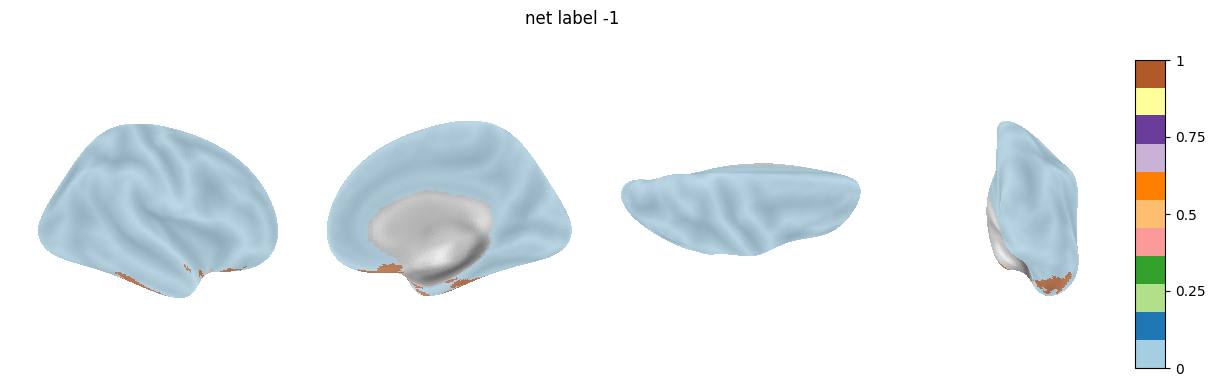

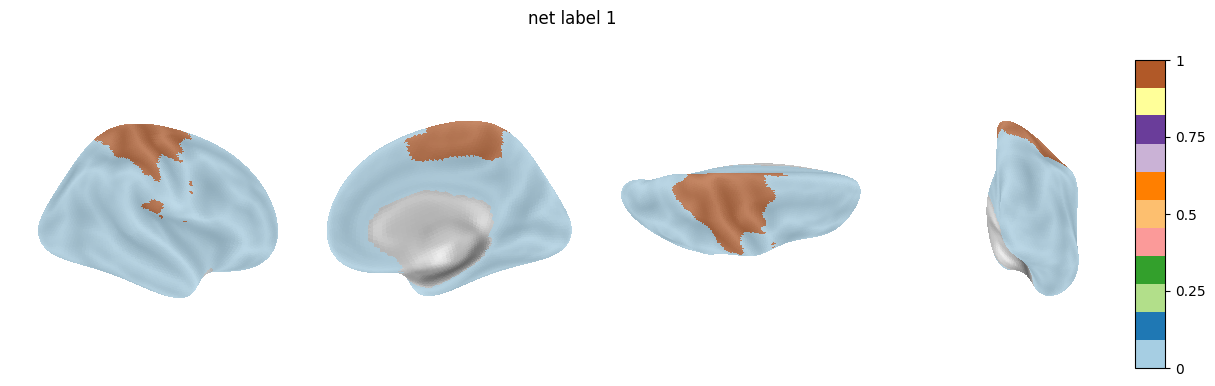

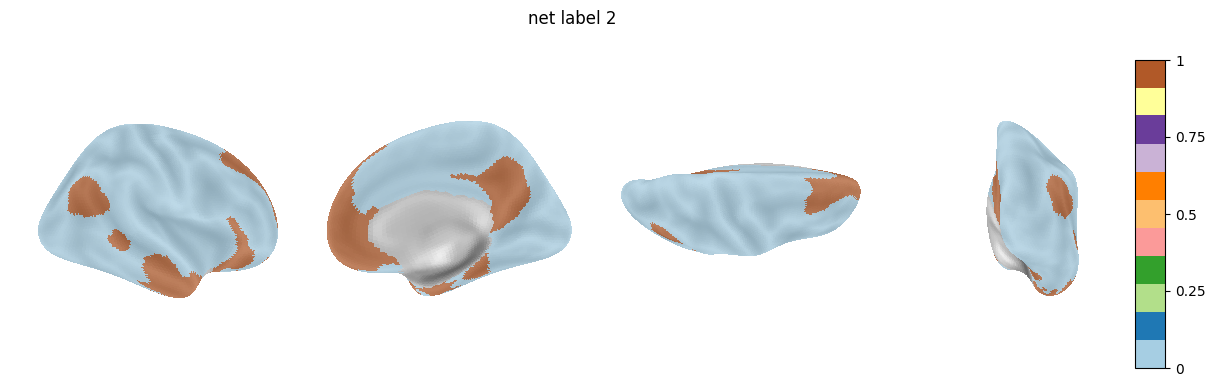

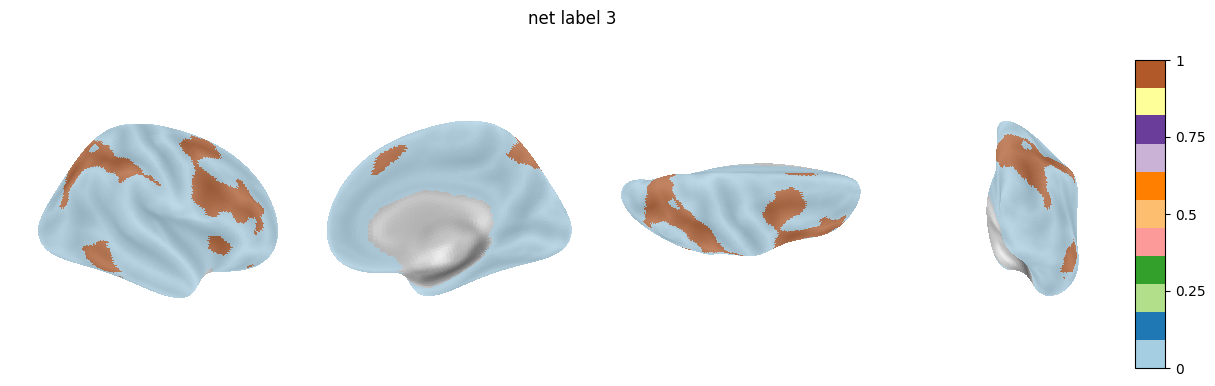

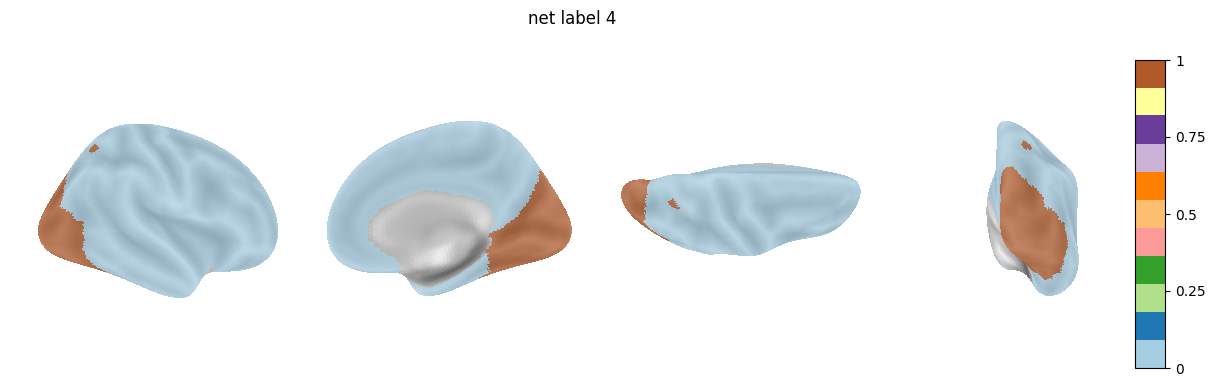

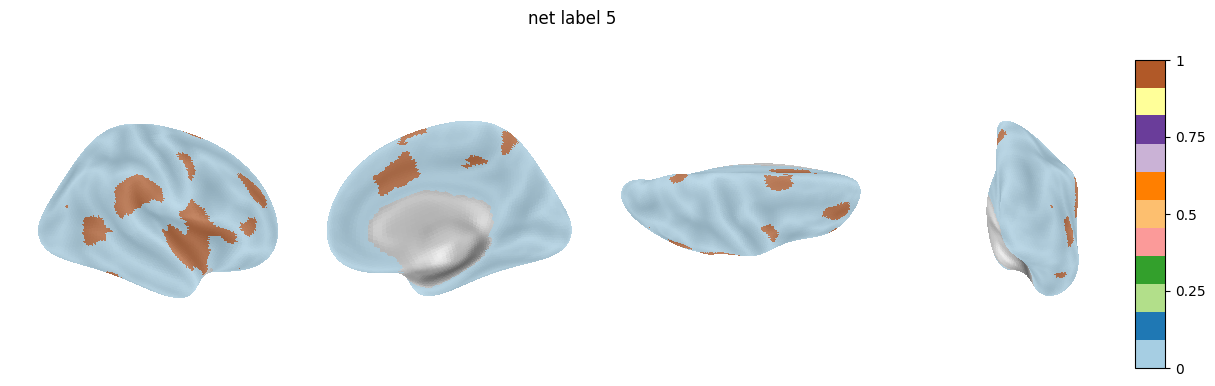

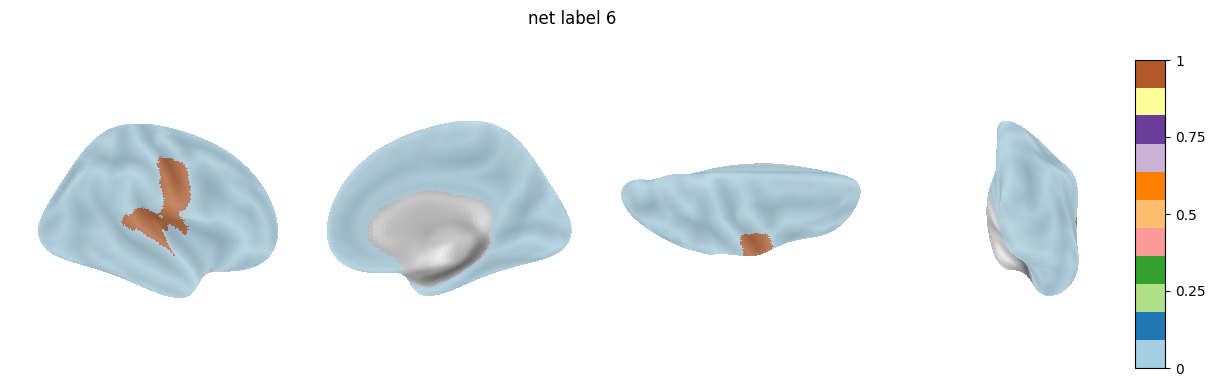

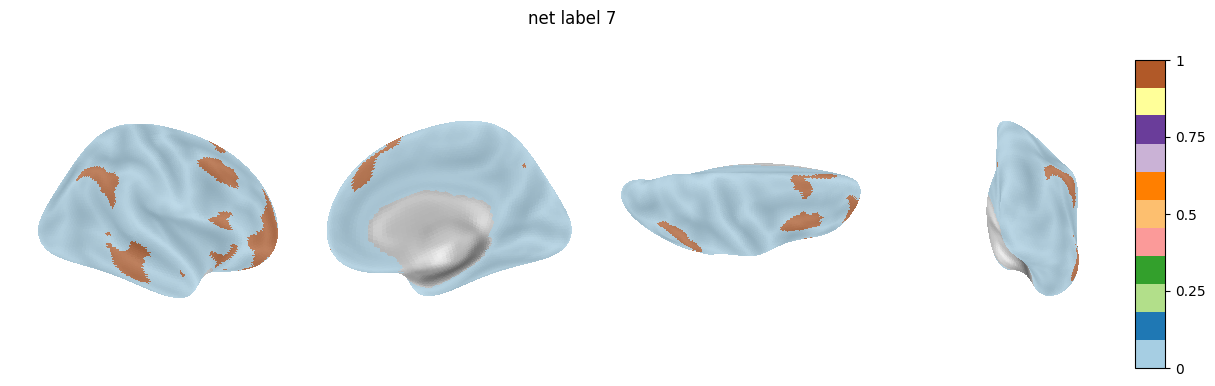

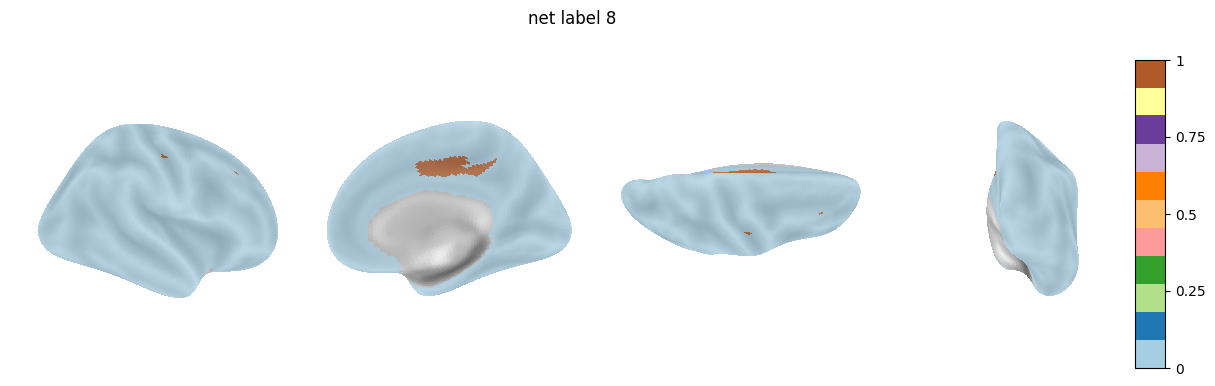

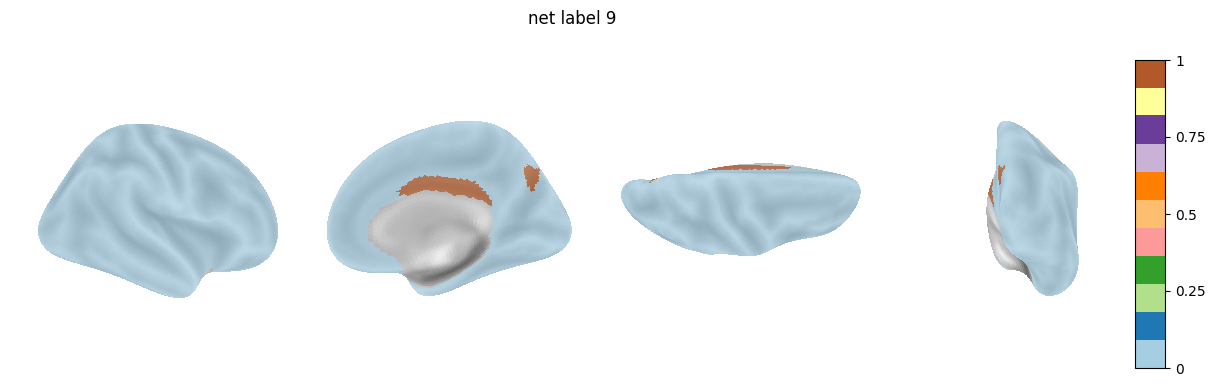

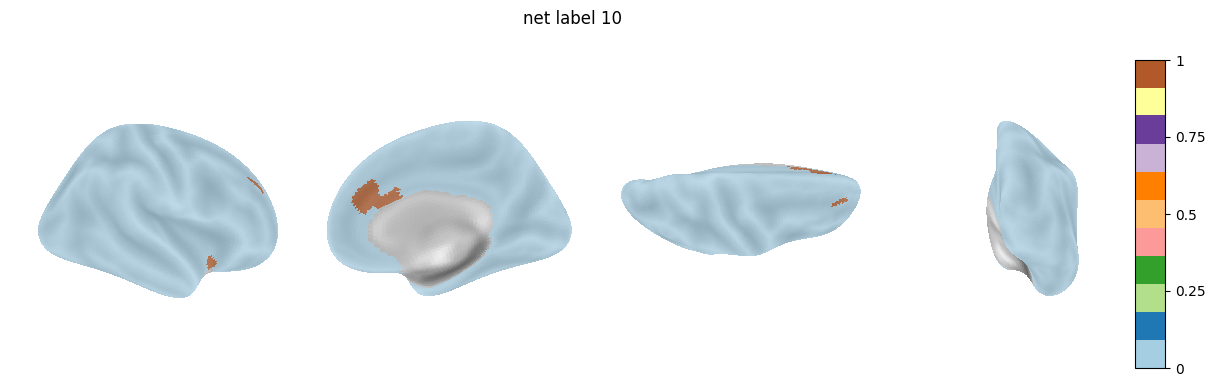

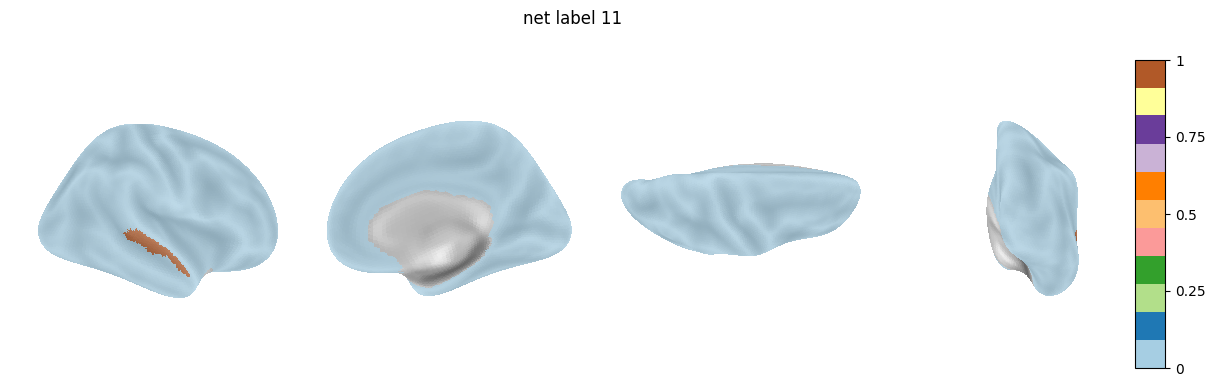

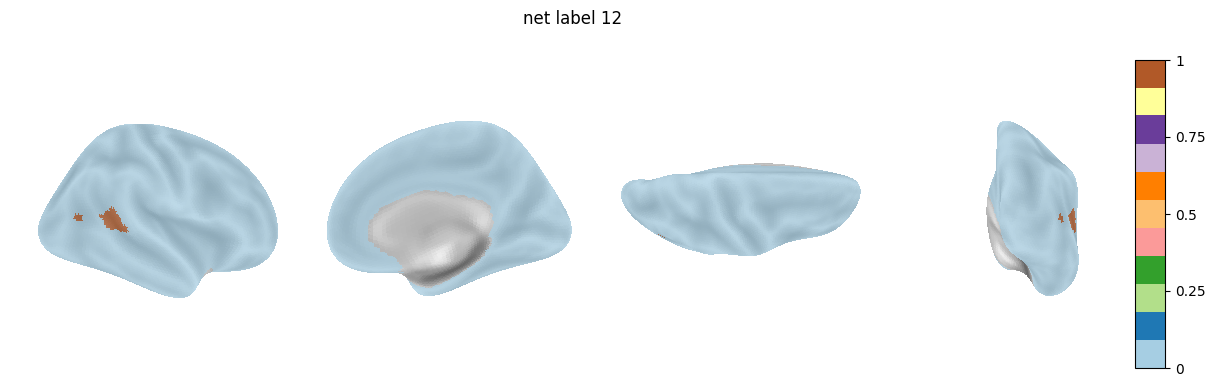

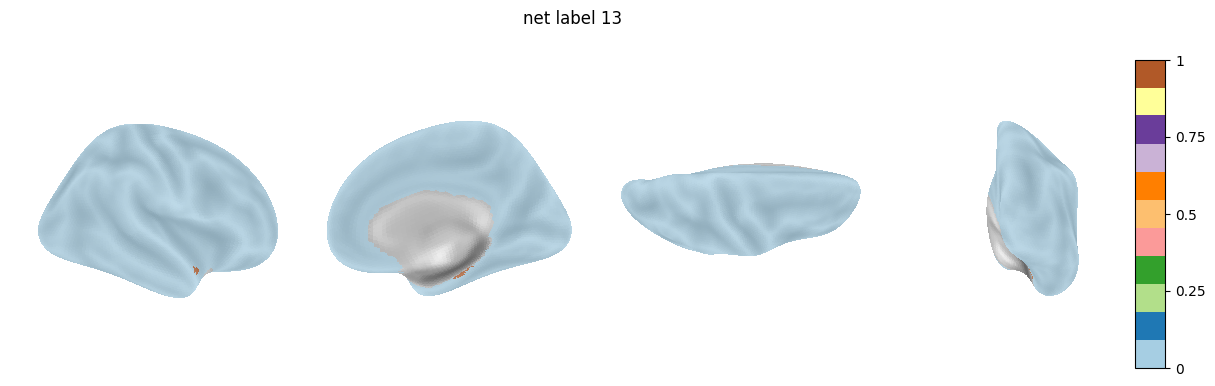

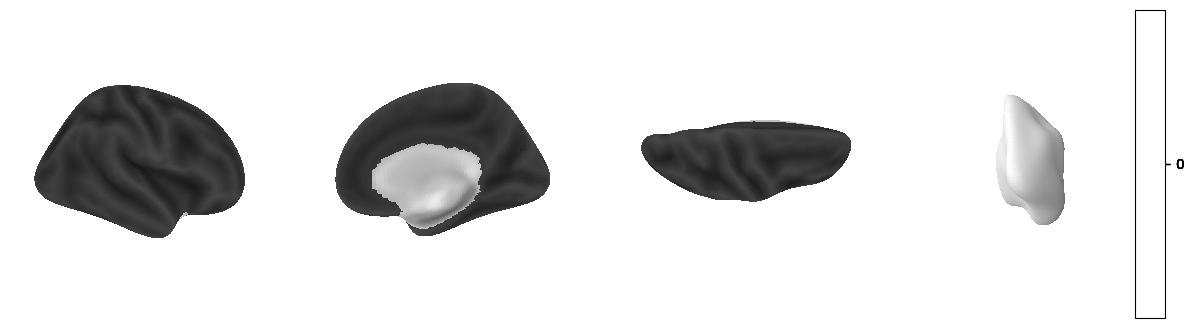

In [29]:
for net_label in np.unique(module_mapping[:,1]):
    singel_module_mask = module_mapping[:,1] == net_label

    modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
    modules_fsav5[mask] = singel_module_mask
    print(modules_fsav5.shape)

    # modules got from run infomap on both, but plot only one hemi
    i_hemi = 0 if hemi_to_plot == 'L' else 1
    modules_fsav5_hemi = np.split(modules_fsav5,2)[i_hemi]
    modules_fsav5_hemi.shape

    map = modules_fsav5_hemi
    hemi_to_plot = hemi if hemi != 'both' else hemi_to_plot
    surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, avg_method = 'median',# infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'net label {net_label}', y=0.75)

In [ ]:
# File reorganization

# rename files 
target_folder = op.join(bids_folder,'derivatives','networks_infomap')

preferred_number_of_modules = 10 # when I run it without specification, should habve been this

for sub in range(1,67):
    old_name = op.join(target_folder, f'sub-{sub:02d}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_confspec-{confspec}.npy')
    new_name = op.join(target_folder, f'sub-{sub:02d}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_prefNmod-{preferred_number_of_modules}_confspec-{confspec}.npy')
    if op.exists(old_name):
        os.rename(old_name, new_name)
        print(f'Renamed {old_name} to {new_name}')
    else:
        print(f'File {old_name} does not exist, skipping renaming.')


# remove all where hemi is not both
confspec = '32Pscrub3BPfilter'

for sub in range(1,67):
    for hemi in ['L', 'R']:
        fn = op.join(target_folder, f'sub-{sub:02d}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}_confspec-{confspec}.npy')
        if op.exists(fn):
            print(f'File {fn} exists, removing it.')
            os.remove(fn)
        else:
            print(f'File {fn} does not exist')

In [ ]:
# make sure color map matches by adding missing labels
network_labels = np.unique(caNets_fsav5_mapping[mask])
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] =  relabeled_subject #caNets_fsav5_mapping[mask] # singel_module_mask
print(modules_fsav5.shape)

surf_map = modules_fsav5.copy()
present_labels = np.unique(surf_map[surf_map != -1])
missing_labels = [l for l in network_labels if l not in present_labels]

unassigned_indices = np.where(surf_map == -1)[0]

# Sanity check: do we have enough unassigned vertices?
assert len(unassigned_indices) >= len(missing_labels), "Not enough unassigned nodes to fake missing labels!"

# Assign one unassigned vertex to each missing label
for label, idx in zip(missing_labels, unassigned_indices[:len(missing_labels)]):
    surf_map[idx] = label

surf_map[surf_map == -1] = 0  # Set all remaining -1 to 0
surf_map[np.isnan(surf_map)] = 0
surf_map = surf_map.astype(int)  # Convert to integer type for plotting